# NBA Graph Strategy — Exploration

End-to-end view: data → three networks → utility network → mispricing → backtest.
Inline knobs in each modelling section so you can iterate without editing modules.

## 0 — Setup

In [9]:
import sys, sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DB_PATH, SEASONS
from src.network.builders import build_passing_network, build_lineup_network, build_team_network
from src.network.utility_net import build_utility_network
from src.network.metrics import summarize, communities

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


## 1 — Data overview

In [10]:
conn = sqlite3.connect(DB_PATH)
tables = [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name").fetchall()]
inv = pd.DataFrame([{"table": t, "rows": conn.execute(f'SELECT COUNT(*) FROM "{t}"').fetchone()[0]} for t in tables])
display(inv.sort_values("rows", ascending=False))
conn.close()

,table,rows
0,lineup_stats_advanced,209574
1,lineup_stats_base,209574
4,passing_received,94992
3,passing_made,94891
5,player_stats_advanced,7411
6,player_stats_base,7411
2,passing_external,5318
7,team_season_features,420
8,team_stats_advanced,420
9,team_stats_base,420


## 2 — Passing network (BOS 2023-24)

In [ ]:
SEASON, TEAM = "2023-24", "BOS"
G = build_passing_network(SEASON, TEAM)
pd.Series(summarize(G)).round(3)


BOS 2023-24: 19 nodes, 216 edges


n_nodes                      19.000
n_edges                     216.000
n_components                  1.000
efficiency                   84.440
degree_entropy                2.331
n_communities                 2.000
modularity_largest_share      0.684
resilience_drop3              0.465
dtype: float64

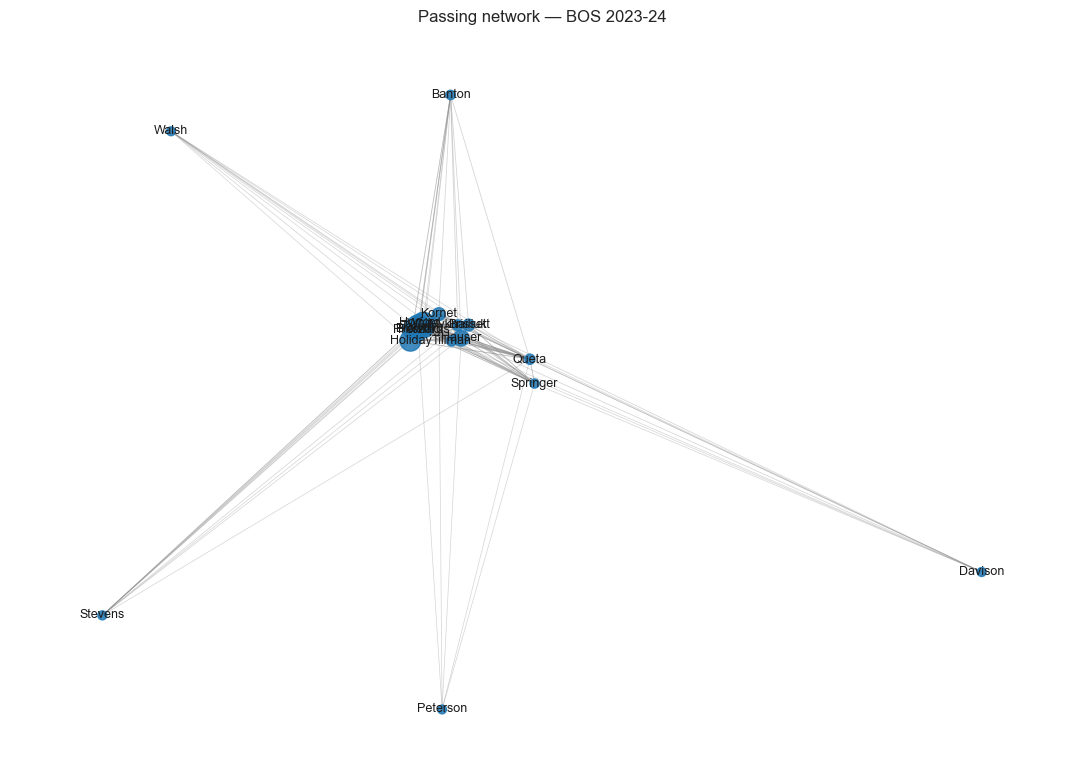

In [4]:
pos = nx.spring_layout(G, seed=7, k=1.2/np.sqrt(max(G.number_of_nodes(),1)))
deg = dict(G.degree(weight="weight"))
node_sizes = [40 + deg[n]/30 for n in G.nodes]
edge_widths = [0.5 + d["weight"]/200 for _,_,d in G.edges(data=True)]
labels = {n: G.nodes[n]["name"].split(",")[0] for n in G.nodes}

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.35, edge_color="#888", arrows=False, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color="#1f77b4", alpha=0.85, ax=ax)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Passing network — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 3 — Lineup network (shared-player edges)

In [5]:
GL = build_lineup_network(SEASON, TEAM, min_minutes=10.0)
comms = communities(GL)
color_map = {n: i for i, c in enumerate(comms) for n in c}
print(f"{TEAM} {SEASON} lineups: {GL.number_of_nodes()} nodes, {GL.number_of_edges()} edges, {len(comms)} communities")


BOS 2023-24 lineups: 91 nodes, 1753 edges, 3 communities


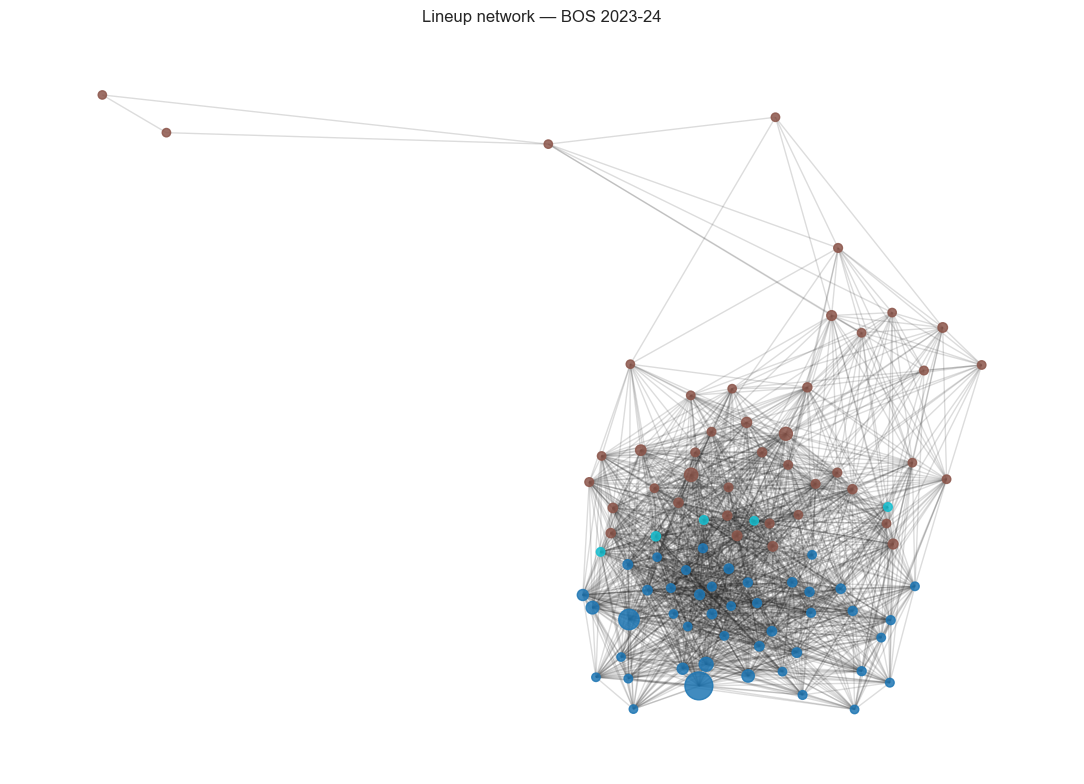

In [6]:
minutes = nx.get_node_attributes(GL, "minutes")
node_sizes = [30 + minutes.get(n,0)*0.6 for n in GL.nodes]
node_colors = [color_map.get(n, -1) for n in GL.nodes]
pos = nx.spring_layout(GL, seed=11, k=2/np.sqrt(max(GL.number_of_nodes(),1)))

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(GL, pos, alpha=0.15, ax=ax)
nx.draw_networkx_nodes(GL, pos, node_size=node_sizes, node_color=node_colors, cmap="tab10", alpha=0.85, ax=ax)
ax.set_title(f"Lineup network — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 4 — Yu & Yang utility network (Havel-Hakimi)

In [ ]:
GU = build_utility_network(SEASON, TEAM)
util = pd.DataFrame([{"player": d["name"], "utility": d["utility"]} for _, d in GU.nodes(data=True)]).sort_values("utility", ascending=False)
display(util)


BOS 2023-24 utility: 17 nodes, 14 edges
utility scores:


,player,utility
5,Jayson Tatum,0.847297
1,Derrick White,0.745832
4,Jaylen Brown,0.745477
8,Kristaps Porziņģis,0.696089
7,Jrue Holiday,0.688678
0,Al Horford,0.550426
12,Payton Pritchard,0.445132
16,Xavier Tillman,0.418897
13,Sam Hauser,0.385342
9,Luke Kornet,0.353560


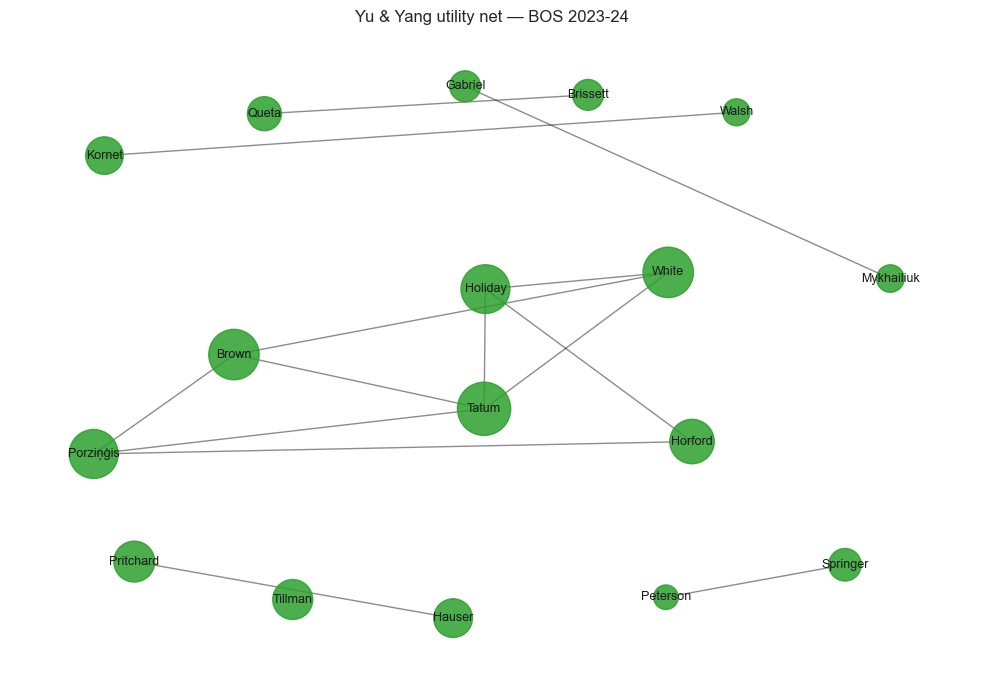

In [8]:
pos = nx.spring_layout(GU, seed=4, k=1.5)
util_vals = nx.get_node_attributes(GU, "utility")
node_sizes = [200 + util_vals[n]*1500 for n in GU.nodes]
labels = {n: GU.nodes[n]["name"].split()[-1] for n in GU.nodes}

fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_edges(GU, pos, alpha=0.5, ax=ax)
nx.draw_networkx_nodes(GU, pos, node_size=node_sizes, node_color="#2ca02c", alpha=0.85, ax=ax)
nx.draw_networkx_labels(GU, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Yu & Yang utility net — {TEAM} {SEASON}")
ax.axis("off")
plt.tight_layout()


## 5 — Team similarity network

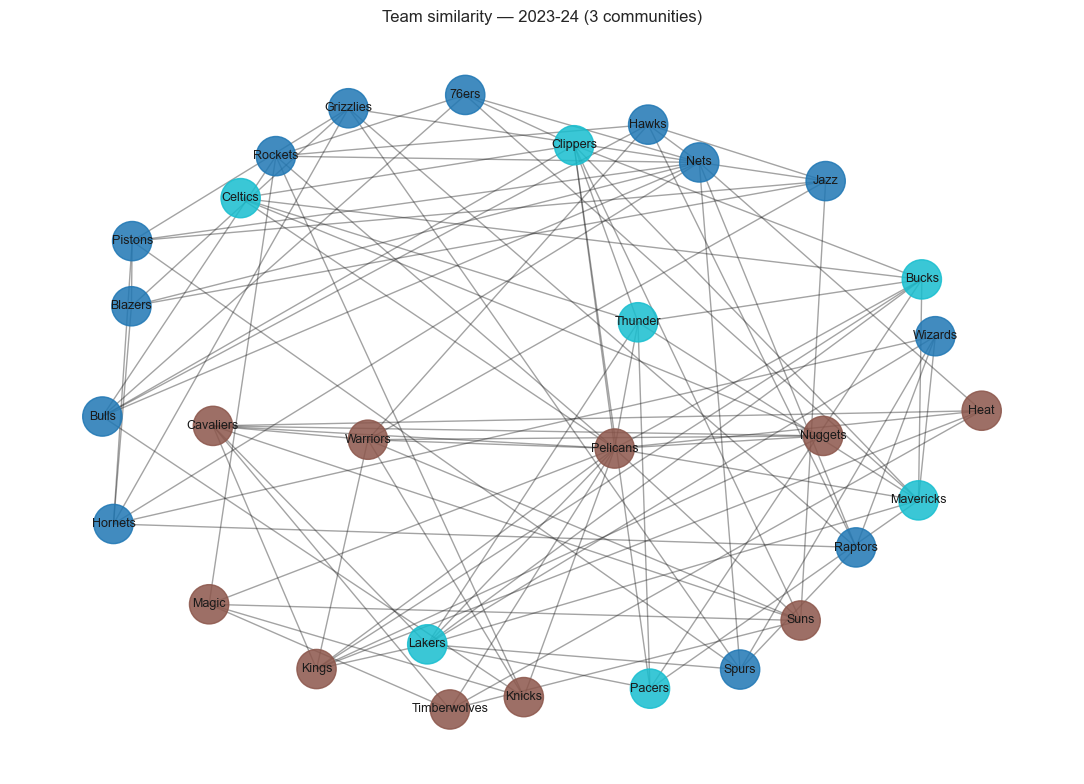

In [9]:
GT = build_team_network(SEASON, k_neighbors=5)
comms_t = communities(GT)
color_map_t = {n: i for i, c in enumerate(comms_t) for n in c}
pos = nx.spring_layout(GT, seed=3, weight="weight", k=1.5)
labels = {n: GT.nodes[n]["name"].split(" ")[-1] for n in GT.nodes}
colors = [color_map_t[n] for n in GT.nodes]

fig, ax = plt.subplots(figsize=(11, 8))
nx.draw_networkx_edges(GT, pos, alpha=0.4, ax=ax)
nx.draw_networkx_nodes(GT, pos, node_size=800, node_color=colors, cmap="tab10", alpha=0.85, ax=ax)
nx.draw_networkx_labels(GT, pos, labels=labels, font_size=9, ax=ax)
ax.set_title(f"Team similarity — {SEASON} ({len(comms_t)} communities)")
ax.axis("off")
plt.tight_layout()
